# EDA Data Overview

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in the first cell for full dataset analysis (production)
- Set `USE_SAMPLE = True` in the first cell for quick sample testing (development)

## Data Distribution

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display


In [2]:
import importlib
import sys
from pathlib import Path

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Resolve project root so notebook can run from any cwd
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from instacart_quality import load_eda_base

# Load clean base tables
base_tables = load_eda_base(use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)
orders = base_tables["orders"]
order_products = base_tables["order_products_prior"]

# Merge for analysis
df = order_products.merge(orders, on="order_id", how="left")

# Feature engineering: cumulative reorder per customer
df = df.sort_values(["user_id", "order_number", "add_to_cart_order"]).reset_index(drop=True)
df["cumulative_reorder_per_customer"] = df.groupby("user_id")["reordered"].cumsum()

print(f"Loaded {len(df):,} order lines from {df['order_id'].nunique():,} orders")
print(f"Serving {df['user_id'].nunique():,} unique customers")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")

Loaded 32,434,489 order lines from 3,214,874 orders
Serving 206,209 unique customers
Data mode: FULL DATASET


In [3]:
df[['user_id', 'order_number', 'product_id', 'reordered','order_hour_of_day','days_since_prior_order','cumulative_reorder_per_customer']].head(10)

,user_id,order_number,product_id,reordered,order_hour_of_day,days_since_prior_order,cumulative_reorder_per_customer
0,1,1,196,0,8,0.0,0
1,1,1,14084,0,8,0.0,0
2,1,1,12427,0,8,0.0,0
3,1,1,26088,0,8,0.0,0
4,1,1,26405,0,8,0.0,0
5,1,2,196,1,7,15.0,1
6,1,2,10258,0,7,15.0,1
7,1,2,12427,1,7,15.0,2
8,1,2,13176,0,7,15.0,2
9,1,2,26088,1,7,15.0,3


In [4]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

<Figure size 700x400 with 0 Axes>

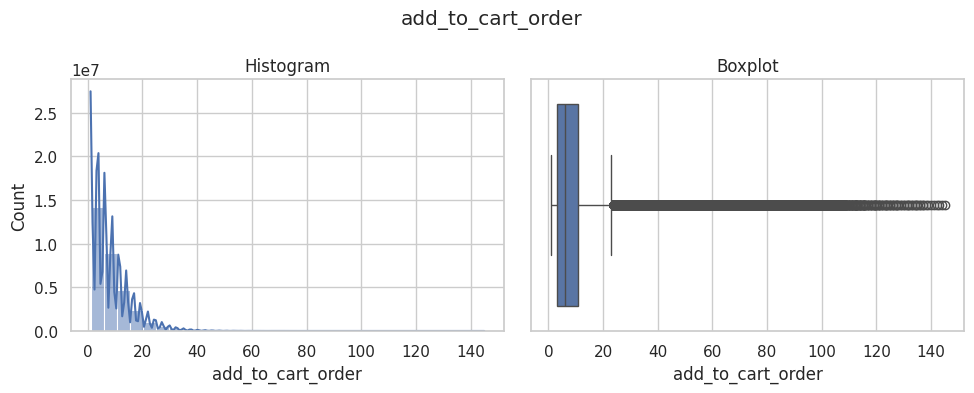

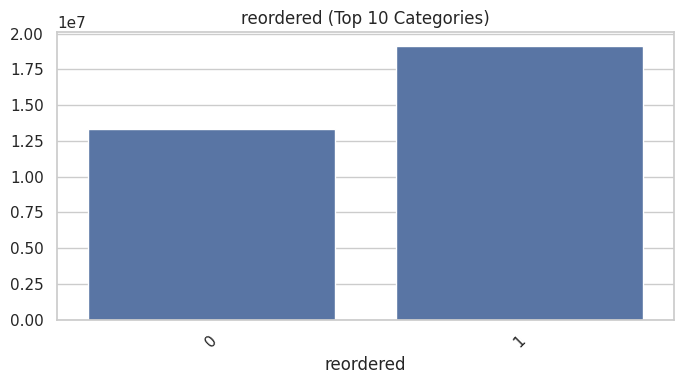

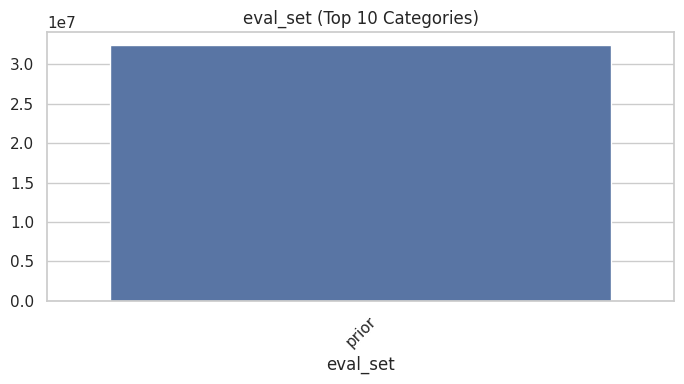

<Figure size 700x400 with 0 Axes>

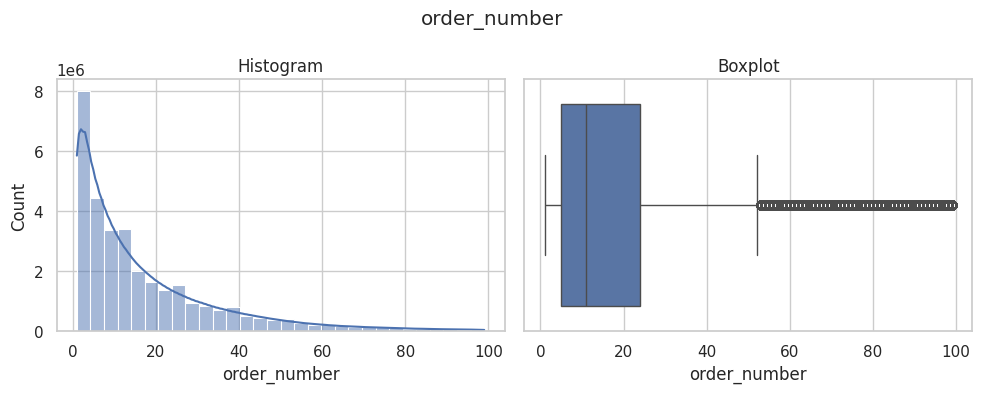

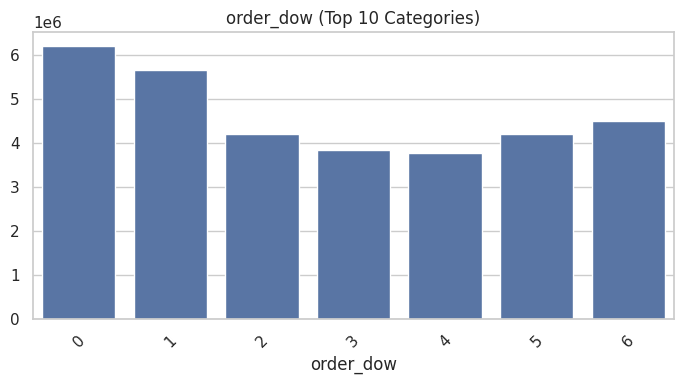

<Figure size 700x400 with 0 Axes>

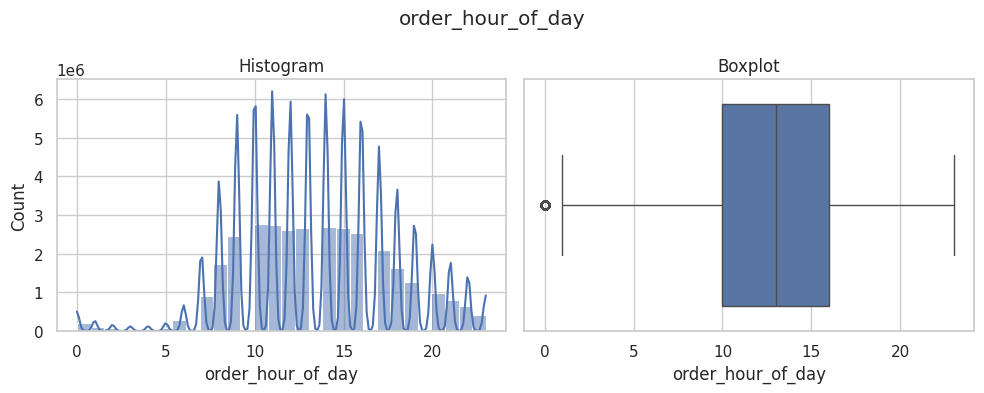

<Figure size 700x400 with 0 Axes>

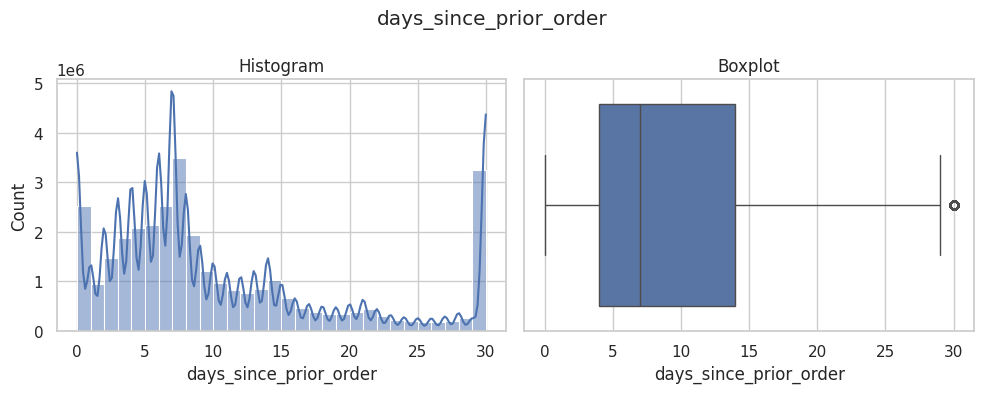

<Figure size 700x400 with 0 Axes>

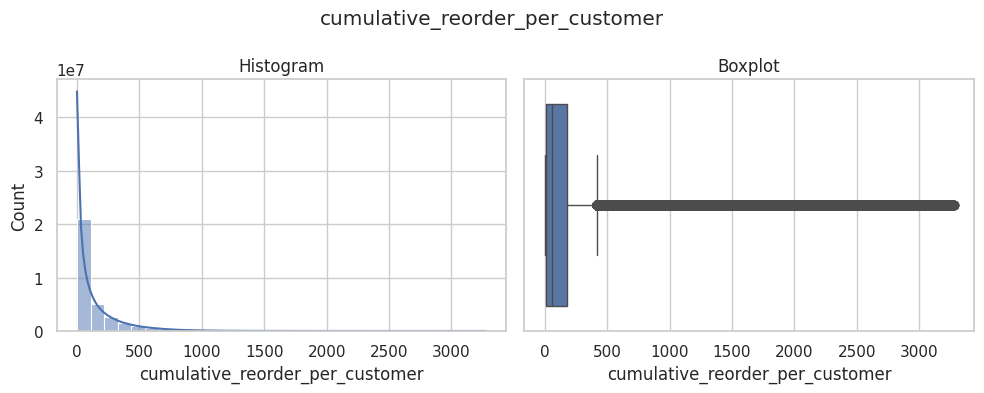

In [5]:
for col in df.columns:
    
    # ❌ ตัด id ออก
    if "id" in col.lower():
        continue

    unique_vals = df[col].nunique()
    plt.figure(figsize=(7, 4))

    # 🟢 CATEGORICAL
    if df[col].dtype == "object" or unique_vals < 10:
        
        # 👉 เอา top 10
        top_vals = df[col].value_counts().nlargest(10)
        
        sns.barplot(x=top_vals.index, y=top_vals.values)
        plt.xticks(rotation=45)
        plt.title(f"{col} (Top 10 Categories)")

    # 🔵 NUMERIC
    elif df[col].dtype in ["int64", "float64"]:
        
        # 🟡 BINARY
        if unique_vals <= 2:
            sns.countplot(x=col, data=df)
            plt.title(f"{col} (Binary)")

        # 🟠 DISCRETE
        elif unique_vals < 20:
            sns.histplot(df[col], bins=min(unique_vals, 15))
            plt.title(f"{col} (Discrete)")

        # 🔴 CONTINUOUS
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            
            sns.histplot(df[col], kde=True, bins=30, ax=axes[0])
            axes[0].set_title("Histogram")

            sns.boxplot(x=df[col], ax=axes[1])
            axes[1].set_title("Boxplot")

            fig.suptitle(col)
            plt.tight_layout()
            plt.show()
            continue

    else:
        plt.close()
        continue

    plt.tight_layout()
    plt.show()

## Next Step

Detailed customer-level bivariate analysis was moved to:
`notebooks/02_Exploratory_Data_Analysis/02_customer_behavior.ipynb`

This overview notebook now focuses on quick distribution scanning only.